In [1]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = r'/Users/admin/dev/algobetting/infra/data/db/fotmob.db'

In [2]:
# =============================================================================
# xG for / against — 10-game rolling average, Superligaen
# =============================================================================
conn = sqlite3.connect(DB_PATH)

# 1. Aggregate xG per team per match from shots
xg = pd.read_sql("""
    SELECT match_id, match_date, teamId AS team_id, SUM(expectedGoals) AS xg_for
    FROM np_shots
    WHERE league_id = 'Superligaen'
    GROUP BY match_id, teamId
""", conn)

# 2. Pull matches so we know who the opponent was
matches = pd.read_sql("""
    SELECT match_id, match_date, home_team, away_team, season
    FROM matches
    WHERE league_id = 'Superligaen'
""", conn)
conn.close()

# 3. Map each team row to its opponent
opp_home = matches[['match_id','home_team','away_team']].rename(columns={'home_team':'team_id','away_team':'opponent_id'})
opp_away = matches[['match_id','away_team','home_team']].rename(columns={'away_team':'team_id','home_team':'opponent_id'})
opp_lookup = pd.concat([opp_home, opp_away])
xg = xg.merge(opp_lookup, on=['match_id','team_id'], how='left')

# 4. Join opponent's xG as xG against
xg_against = xg[['match_id','team_id','xg_for']].rename(columns={'team_id':'opponent_id','xg_for':'xg_against'})
xg = xg.merge(xg_against, on=['match_id','opponent_id'], how='left')

# 5. Add team names
conn = sqlite3.connect(DB_PATH)
names = pd.read_sql("SELECT team_id, team_name FROM team_id_mapping", conn)
conn.close()
xg = xg.merge(names, on='team_id', how='left')
xg['match_date'] = pd.to_datetime(xg['match_date'])
xg = xg.sort_values(['team_id','match_date'])

# 6. 10-game rolling averages per team
xg['xg_for_roll10']     = xg.groupby('team_id')['xg_for'].transform(lambda x: x.rolling(10, min_periods=3).mean())
xg['xg_against_roll10'] = xg.groupby('team_id')['xg_against'].transform(lambda x: x.rolling(10, min_periods=3).mean())
xg['xg_diff_roll10']    = xg['xg_for_roll10'] - xg['xg_against_roll10']

print(f"Matches loaded: {xg['match_id'].nunique()}")
print(f"Teams:          {xg['team_name'].nunique()}")
print(f"Date range:     {xg['match_date'].min().date()} → {xg['match_date'].max().date()}")
xg[['team_name','match_date','xg_for','xg_against','xg_for_roll10','xg_against_roll10','xg_diff_roll10']].tail(20)

Matches loaded: 339
Teams:          12
Date range:     2024-07-19 → 2026-04-05


,team_name,match_date,xg_for,xg_against,xg_for_roll10,xg_against_roll10,xg_diff_roll10
435,Nordsjælland,2025-08-15,0.810940,0.677493,1.078622,1.509247,-0.430625
457,Nordsjælland,2025-08-25,0.697044,0.621865,1.031946,1.252777,-0.220830
465,Nordsjælland,2025-08-31,1.057513,1.322521,1.023961,1.211609,-0.187648
477,Nordsjælland,2025-09-14,1.545957,0.333060,1.017208,1.139054,-0.121846
491,Nordsjælland,2025-09-22,1.201545,1.532082,1.029922,1.220653,-0.190731
501,Nordsjælland,2025-09-28,0.433172,1.664231,1.038819,1.246174,-0.207356
517,Nordsjælland,2025-10-05,2.898403,0.921362,1.223787,1.190741,0.033046
521,Nordsjælland,2025-10-19,1.459175,1.677547,1.224240,1.276189,-0.051949
531,Nordsjælland,2025-10-24,0.650742,1.690961,1.152109,1.292473,-0.140363
543,Nordsjælland,2025-11-02,2.471727,1.824640,1.322622,1.226576,0.096046


In [3]:
xg['team_name'].drop_duplicates()

0                 AGF
1      FC Midtjylland
6      Vejle Boldklub
10       FC København
7          Randers FC
395                OB
4           Silkeborg
388        Fredericia
2                 NaN
5         Sønderjyske
8          Brøndby IF
9              Viborg
3        Nordsjælland
Name: team_name, dtype: str

In [4]:
xg[xg['team_name'] == 'FC København'].tail(20)

,match_id,match_date,team_id,xg_for,opponent_id,xg_against,team_name,xg_for_roll10,xg_against_roll10,xg_diff_roll10
446,4801962,2025-08-23,8391,1.061581,8414,1.257681,FC København,1.859689,0.951407,0.908282
466,4801972,2025-08-31,8391,2.390494,8410,0.431693,FC København,1.959743,0.888075,1.071668
470,4801974,2025-09-13,8391,0.507718,8595,1.217528,FC København,1.832020,0.942864,0.889156
484,4801981,2025-09-21,8391,2.618597,8415,1.450458,FC København,1.716388,1.052044,0.664344
502,4801990,2025-09-27,8391,2.441837,8487,0.555375,FC København,1.819670,1.073161,0.746509
509,4801993,2025-10-05,8391,1.490901,8113,0.781388,FC København,1.697463,1.042177,0.655286
524,4802001,2025-10-17,8391,2.320678,8415,1.474704,FC København,1.790163,1.062250,0.727914
532,4802005,2025-10-26,8391,1.356508,9939,0.362723,FC København,1.729789,1.048609,0.681181
550,4802014,2025-11-01,8391,0.890820,8454,0.953775,FC København,1.575663,0.929626,0.646036
563,4802020,2025-11-09,8391,0.853839,8231,1.007728,FC København,1.593297,0.949305,0.643992


In [5]:
# =============================================================================
# Datawrapper export — FC København xG for/against 10-game rolling average
# =============================================================================
fck = xg[xg['team_name'] == 'FC København'][
    ['match_id', 'match_date', 'xg_for_roll10', 'xg_against_roll10']
].dropna().copy()

# Add season
fck = fck.merge(matches[['match_id', 'season']].drop_duplicates(), on='match_id', how='left')

# Single index ordered by date across both seasons
fck = fck.sort_values('match_date').reset_index(drop=True)
fck['Game'] = fck.index + 1

fck = fck[['Game', 'season', 'xg_for_roll10', 'xg_against_roll10']].rename(
    columns={'season': 'Season', 'xg_for_roll10': 'xG for (10-game avg)', 'xg_against_roll10': 'xG against (10-game avg)'})
fck[['xG for (10-game avg)', 'xG against (10-game avg)']] = fck[['xG for (10-game avg)', 'xG against (10-game avg)']].round(2)

print("--- COPY EVERYTHING BELOW THIS LINE ---")
print(fck.to_csv(index=False))

--- COPY EVERYTHING BELOW THIS LINE ---
Game,Season,xG for (10-game avg),xG against (10-game avg)
1,2024-2025,1.54,1.01
2,2024-2025,1.87,0.87
3,2024-2025,1.79,0.89
4,2024-2025,1.75,1.04
5,2024-2025,1.64,1.21
6,2024-2025,1.52,1.17
7,2024-2025,1.71,1.06
8,2024-2025,1.72,1.05
9,2024-2025,1.74,1.19
10,2024-2025,1.86,1.14
11,2024-2025,1.69,1.08
12,2024-2025,1.72,1.08
13,2024-2025,1.65,1.21
14,2024-2025,1.8,1.11
15,2024-2025,1.77,0.93
16,2024-2025,1.77,0.92
17,2024-2025,1.68,1.0
18,2024-2025,1.59,1.02
19,2024-2025,1.55,0.84
20,2024-2025,1.53,1.02
21,2024-2025,1.58,0.98
22,2024-2025,1.33,0.96
23,2024-2025,1.34,0.8
24,2024-2025,1.19,0.9
25,2024-2025,1.28,0.98
26,2024-2025,1.36,1.09
27,2024-2025,1.28,1.11
28,2024-2025,1.36,1.06
29,2024-2025,1.6,1.06
30,2024-2025,1.53,0.86
31,2025-2026,1.72,0.94
32,2025-2026,1.8,1.04
33,2025-2026,1.91,1.03
34,2025-2026,2.0,1.07
35,2025-2026,1.91,1.02
36,2025-2026,1.86,0.95
37,2025-2026,1.96,0.89
38,2025-2026,1.83,0.94
39,2025-2026,1.72,1.05
40,2025-2026,1.82,1.0

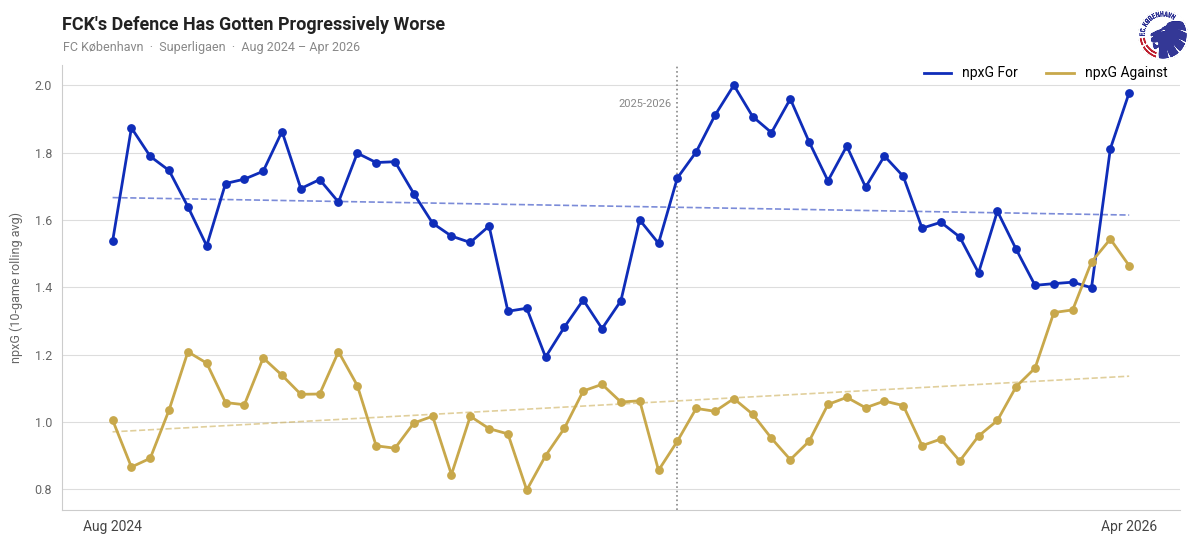

In [6]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.npxg_trend_chart import plot_xg_trend

plot_df = xg[xg['team_name'] == 'FC København'].dropna(
    subset=['xg_for_roll10', 'xg_against_roll10']
).merge(matches[['match_id', 'season']].drop_duplicates(), on='match_id', how='left')

title = "FCK's Defence Has Gotten Progressively Worse"  # ← edit this

plot_xg_trend(
    plot_df=plot_df,
    title=title,
    team="FC København",
    league="Superligaen",
    save_path="fck_xg_rolling.png",
)

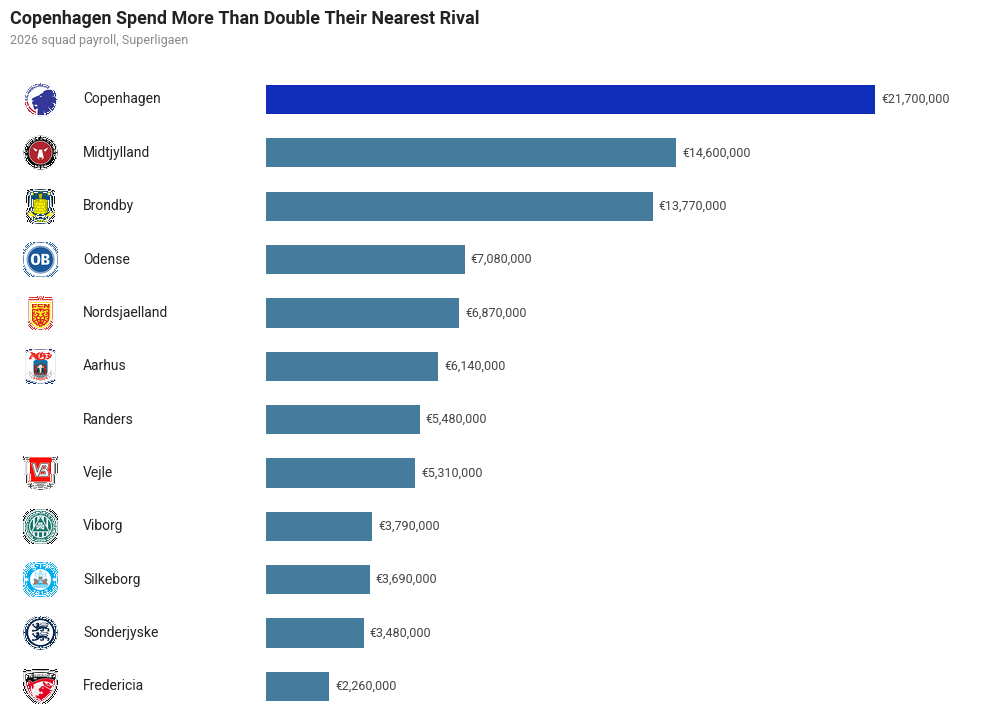

--- COPY EVERYTHING BELOW THIS LINE ---
Logo,Team,2026 Payroll
![](https://r2.thesportsdb.com/images/media/team/badge/styqtr1473535513.png),Copenhagen,21700000
![](https://r2.thesportsdb.com/images/media/team/badge/s5bpcr1755712262.png),Midtjylland,14600000
![](https://r2.thesportsdb.com/images/media/team/badge/ywswyw1473535498.png),Brondby,13770000
![](https://r2.thesportsdb.com/images/media/team/badge/syyxwq1473535545.png),Odense,7080000
![](https://r2.thesportsdb.com/images/media/team/badge/p2hof41579460164.png),Nordsjaelland,6870000
![](https://r2.thesportsdb.com/images/media/team/badge/vxuuts1473535487.png),Aarhus,6140000
![](https://upload.wikimedia.org/wikipedia/en/thumb/b/b7/Randers_FC_logo.svg/250px-Randers_FC_logo.svg.png),Randers,5480000
![](https://r2.thesportsdb.com/images/media/team/badge/fhlqev1532855346.png),Vejle,5310000
![](https://r2.thesportsdb.com/images/media/team/badge/uvrpsp1447539333.png),Viborg,3790000
![](https://r2.thesportsdb.com/images/media/team/badge/tpx

In [7]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.bar_chart import plot_bar_chart, datawrapper_csv

payroll = {
    "Copenhagen":    21_700_000,
    "Midtjylland":   14_600_000,
    "Brondby":       13_770_000,
    "Odense":         7_080_000,
    "Nordsjaelland":  6_870_000,
    "Aarhus":         6_140_000,
    "Randers":        5_480_000,
    "Vejle":          5_310_000,
    "Viborg":         3_790_000,
    "Silkeborg":      3_690_000,
    "Sonderjyske":    3_480_000,
    "Fredericia":     2_260_000,
}

title    = "Copenhagen Spend More Than Double Their Nearest Rival"  # ← edit
subtitle = "2026 squad payroll, Superligaen"

plot_bar_chart(
    data=payroll,
    title=title,
    subtitle=subtitle,
    value_format="€{:,.0f}",
    highlight_team="Copenhagen",
    save_path="superligaen_payroll.png",
)

# Datawrapper CSV export
datawrapper_csv(payroll, value_label="2026 Payroll")

In [8]:
# =============================================================================
# FCK Season Comparison — diagnostic breakdown
# =============================================================================
FCK_ID = 8391

conn = sqlite3.connect(DB_PATH)

# npxG + shot counts for FCK
npshots_fck = pd.read_sql("""
    SELECT match_id, season,
           SUM(expectedGoals) AS npxg_for,
           COUNT(*)           AS np_shots_for
    FROM np_shots
    WHERE league_id = 'Superligaen'
      AND teamId = 8391
    GROUP BY match_id, season
""", conn)

# Opponent npxG/shots in same matches
npshots_opp = pd.read_sql("""
    SELECT match_id,
           SUM(expectedGoals) AS npxg_against,
           COUNT(*)           AS np_shots_against
    FROM np_shots
    WHERE league_id = 'Superligaen'
      AND teamId != 8391
      AND match_id IN (
            SELECT DISTINCT match_id FROM np_shots
            WHERE teamId = 8391 AND league_id = 'Superligaen'
          )
    GROUP BY match_id
""", conn)

# Non-penalty goals (actual scoreline)
goals = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391 THEN home_goals ELSE away_goals END AS goals_for,
           CASE WHEN home_team = 8391 THEN away_goals ELSE home_goals END AS goals_against
    FROM np_matches
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)

# PSxG = expected_goals_on_target + total shots from match_stats
ms = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391
                THEN home_expected_goals_on_target
                ELSE away_expected_goals_on_target END AS psxg_for,
           CASE WHEN home_team = 8391
                THEN away_expected_goals_on_target
                ELSE home_expected_goals_on_target END AS psxg_against,
           CASE WHEN home_team = 8391
                THEN home_total_shots ELSE away_total_shots END AS shots_for,
           CASE WHEN home_team = 8391
                THEN away_total_shots ELSE home_total_shots END AS shots_against
    FROM match_stats
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)

# Penalties awarded for and against
pens = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391 THEN home_pens ELSE away_pens END AS pens_for,
           CASE WHEN home_team = 8391 THEN away_pens ELSE home_pens END AS pens_against
    FROM penalties
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)

# Total xG for FCK (including penalties)
xg_fck = pd.read_sql("""
    SELECT match_id,
           SUM(expectedGoals) AS xg_for
    FROM shots
    WHERE league_id = 'Superligaen'
      AND teamId = 8391
    GROUP BY match_id
""", conn)

# Total xG against FCK (including penalties)
xg_opp = pd.read_sql("""
    SELECT match_id,
           SUM(expectedGoals) AS xg_against
    FROM shots
    WHERE league_id = 'Superligaen'
      AND teamId != 8391
      AND match_id IN (
            SELECT DISTINCT match_id FROM shots
            WHERE teamId = 8391 AND league_id = 'Superligaen'
          )
    GROUP BY match_id
""", conn)

conn.close()

# Coerce text columns
for col in ['psxg_for', 'psxg_against', 'shots_for', 'shots_against']:
    ms[col] = pd.to_numeric(ms[col], errors='coerce')

# ── Merge ─────────────────────────────────────────────────────────────────────
df = (npshots_fck
      .merge(npshots_opp, on='match_id', how='left')
      .merge(goals,       on='match_id', how='left')
      .merge(ms,          on='match_id', how='left')
      .merge(pens,        on='match_id', how='left')
      .merge(xg_fck,      on='match_id', how='left')
      .merge(xg_opp,      on='match_id', how='left'))

# ── Derived metrics ───────────────────────────────────────────────────────────
df['xgd']                  = df['xg_for']        - df['xg_against']
df['npxgd']                = df['npxg_for']      - df['npxg_against']
df['goals_minus_npxg']     = df['goals_for']     - df['npxg_for']
df['ga_minus_npxga']       = df['goals_against'] - df['npxg_against']
df['npxg_per_shot_for']    = df['npxg_for']      / df['np_shots_for']
df['npxg_per_shot_ag']     = df['npxg_against']  / df['np_shots_against']
df['psxg_diff_for']        = df['psxg_for']      - df['npxg_for']
df['psxg_diff_ag']         = df['psxg_against']  - df['npxg_against']
df['goals_minus_psxg_for'] = df['goals_for']     - df['psxg_for']
df['goals_minus_psxg_ag']  = df['goals_against'] - df['psxg_against']

# ── Season averages ───────────────────────────────────────────────────────────
comp = df.groupby('season').agg(
    Games               = ('match_id',             'count'),
    xG_for              = ('xg_for',              'mean'),
    xGA                 = ('xg_against',          'mean'),
    xGD                 = ('xgd',                 'mean'),
    npxG_for            = ('npxg_for',             'mean'),
    npxGA               = ('npxg_against',          'mean'),
    npxGD               = ('npxgd',                'mean'),
    Goals_for           = ('goals_for',            'mean'),
    Goals_against       = ('goals_against',        'mean'),
    Goals_minus_npxG    = ('goals_minus_npxg',     'mean'),
    GA_minus_npxGA      = ('ga_minus_npxga',       'mean'),
    PSxG_for            = ('psxg_for',             'mean'),
    PSxG_against        = ('psxg_against',         'mean'),
    PSxG_diff_for       = ('psxg_diff_for',        'mean'),
    PSxG_diff_ag        = ('psxg_diff_ag',         'mean'),
    Goals_minus_PSxG    = ('goals_minus_psxg_for', 'mean'),
    GA_minus_PSxG       = ('goals_minus_psxg_ag',  'mean'),
    npxG_per_shot_for   = ('npxg_per_shot_for',    'mean'),
    npxG_per_shot_ag    = ('npxg_per_shot_ag',     'mean'),
    Shots_for_pg        = ('shots_for',            'mean'),
    Shots_against_pg    = ('shots_against',        'mean'),
    Pens_for            = ('pens_for',             'sum'),
    Pens_against        = ('pens_against',         'sum'),
).round(3)

comp.T

season,2024-2025,2025-2026
Games,32.000,25.000
xG_for,1.819,1.985
xGA,1.073,1.387
xGD,0.746,0.597
npxG_for,1.622,1.796
npxGA,0.999,1.198
npxGD,0.623,0.597
Goals_for,1.656,1.520
Goals_against,0.938,1.280
Goals_minus_npxG,0.034,-0.276


In [9]:
# =============================================================================
# Datawrapper table exports — key metrics, attack & defence
# =============================================================================
import io, csv

s24, s25 = '2024-2025', '2025-2026'
c = comp

def dw_table(metrics, label):
    out = io.StringIO()
    w = csv.writer(out)
    w.writerow(['Metric', '2024-25', '2025-26'])
    for display_label, col in metrics:
        v24 = round(c.loc[s24, col], 2)
        v25 = round(c.loc[s25, col], 2)
        w.writerow([display_label, v24, v25])
    print(f"--- {label} — COPY EVERYTHING BELOW ---")
    print(out.getvalue())

dw_table([
    ('xG for per game',        'xG_for'),
    ('xG against per game',    'xGA'),
    ('xG diff per game',       'xGD'),
    ('npxG for per game',      'npxG_for'),
    ('npxG against per game',  'npxGA'),
    ('npxG diff per game',     'npxGD'),
    ('Shots per game',        'Shots_for_pg'),
    ('npxG per shot',         'npxG_per_shot_for'),
    ('Goals per game',        'Goals_for'),
    ('Goals vs npxG',         'Goals_minus_npxG'),
    ('Shot placement (PSxG-npxG)', 'PSxG_diff_for'),
], 'ATTACK')

dw_table([
    ('npxGA per game',              'npxGA'),
    ('Shots against per game',      'Shots_against_pg'),
    ('Opp. npxG per shot',          'npxG_per_shot_ag'),
    ('Goals conceded per game',     'Goals_against'),
    ('GA vs npxGA',                 'GA_minus_npxGA'),
    ('Opp. shot placement (PSxG-npxG)', 'PSxG_diff_ag'),
    ('Penalties conceded',          'Pens_against'),
], 'DEFENCE')

--- ATTACK — COPY EVERYTHING BELOW ---
Metric,2024-25,2025-26
xG for per game,1.82,1.98
xG against per game,1.07,1.39
xG diff per game,0.75,0.6
npxG for per game,1.62,1.8
npxG against per game,1.0,1.2
npxG diff per game,0.62,0.6
Shots per game,15.75,17.16
npxG per shot,0.11,0.1
Goals per game,1.66,1.52
Goals vs npxG,0.03,-0.28
Shot placement (PSxG-npxG),0.34,0.12

--- DEFENCE — COPY EVERYTHING BELOW ---
Metric,2024-25,2025-26
npxGA per game,1.0,1.2
Shots against per game,9.84,9.64
Opp. npxG per shot,0.11,0.13
Goals conceded per game,0.94,1.28
GA vs npxGA,-0.06,0.08
Opp. shot placement (PSxG-npxG),-0.0,0.22
Penalties conceded,3,6



In [10]:
# =============================================================================
# Datawrapper table — summary differentials
# =============================================================================
import io, csv

s24, s25 = '2024-2025', '2025-2026'
c = comp

# Compute GD from goals for/against
gd_24 = round(c.loc[s24, 'Goals_for']    - c.loc[s24, 'Goals_against'], 2)
gd_25 = round(c.loc[s25, 'Goals_for']    - c.loc[s25, 'Goals_against'], 2)

out = io.StringIO()
w = csv.writer(out)
w.writerow(['Metric', '2024-25', '2025-26'])
w.writerow(['npxGD per game',    round(c.loc[s24, 'npxGD'], 2),           round(c.loc[s25, 'npxGD'], 2)])
w.writerow(['GD per game',       gd_24,                                    gd_25])
w.writerow(['Goals vs npxG',     round(c.loc[s24, 'Goals_minus_npxG'], 2), round(c.loc[s25, 'Goals_minus_npxG'], 2)])
w.writerow(['GA vs npxGA',       round(c.loc[s24, 'GA_minus_npxGA'], 2),   round(c.loc[s25, 'GA_minus_npxGA'], 2)])
w.writerow(['Shot placement for (PSxG-npxG)', round(c.loc[s24, 'PSxG_diff_for'], 2), round(c.loc[s25, 'PSxG_diff_for'], 2)])
w.writerow(['Shot placement ag (PSxG-npxG)',  round(c.loc[s24, 'PSxG_diff_ag'], 2),  round(c.loc[s25, 'PSxG_diff_ag'], 2)])

print("--- SUMMARY — COPY EVERYTHING BELOW ---")
print(out.getvalue())

--- SUMMARY — COPY EVERYTHING BELOW ---
Metric,2024-25,2025-26
npxGD per game,0.62,0.6
GD per game,0.72,0.24
Goals vs npxG,0.03,-0.28
GA vs npxGA,-0.06,0.08
Shot placement for (PSxG-npxG),0.34,0.12
Shot placement ag (PSxG-npxG),-0.0,0.22



In [11]:
# # =============================================================================
# # Datawrapper table — FCK player finishing 2025-26 (min 5 shots)
# # =============================================================================
# import io, csv

# player_shots['is_goal'] = (player_shots['eventType'] == 'Goal').astype(int)

# p25 = (player_shots[player_shots['season'] == '2025-2026']
#     .groupby('playerName')
#     .agg(Shots=('expectedGoals','count'), npxG=('expectedGoals','sum'), Goals=('is_goal','sum'))
#     .reset_index()
# )
# p25['Goals_vs_npxG'] = (p25['Goals'] - p25['npxG']).round(2)
# p25['npxG']          = p25['npxG'].round(2)
# p25 = p25[p25['Shots'] >= 5].sort_values('npxG', ascending=False)

# out = io.StringIO()
# w = csv.writer(out)
# w.writerow(['Player', 'Shots', 'npxG', 'Goals', 'Goals vs npxG'])
# for _, row in p25.iterrows():
#     w.writerow([
#         row['playerName'],
#         int(row['Shots']),
#         row['npxG'],
#         int(row['Goals']),
#         row['Goals_vs_npxG'],
#     ])

# print("--- PLAYER FINISHING — COPY EVERYTHING BELOW ---")
# print(out.getvalue())

In [12]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from infra.data.feature_engineering.team_stats import (
    get_standard_stats, ATTACK_METRICS, DEFENCE_METRICS
)

DB = '/Users/admin/dev/algobetting/infra/data/db/fotmob.db'
s24, s25 = '2024-2025', '2025-2026'

# All teams — used for radar axis scaling
league_stats = get_standard_stats(DB, 'Superligaen')

# FCK indexed by season — used for radar charts
comp = (
    get_standard_stats(DB, 'Superligaen', seasons=[s24, s25])
    .pipe(lambda df: df[df['team_name'] == 'FC København'])
    .set_index('season')
)
comp


,team_name,npxG_for,npxGA,npxG_per_shot_for,npxG_per_shot_ag,shots_for,shots_against,sp_xg_for,sp_xg_against,box_touches_for,box_touches_against,possession,opp_pass_pct
season,,,,,,,,,,,,,
2024-2025,FC København,1.622,0.999,0.112,0.110,15.75,9.844,0.295,0.257,29.156,17.969,53.375,81.156
2025-2026,FC København,1.796,1.198,0.105,0.128,17.16,9.640,0.442,0.360,34.000,17.320,54.920,79.960


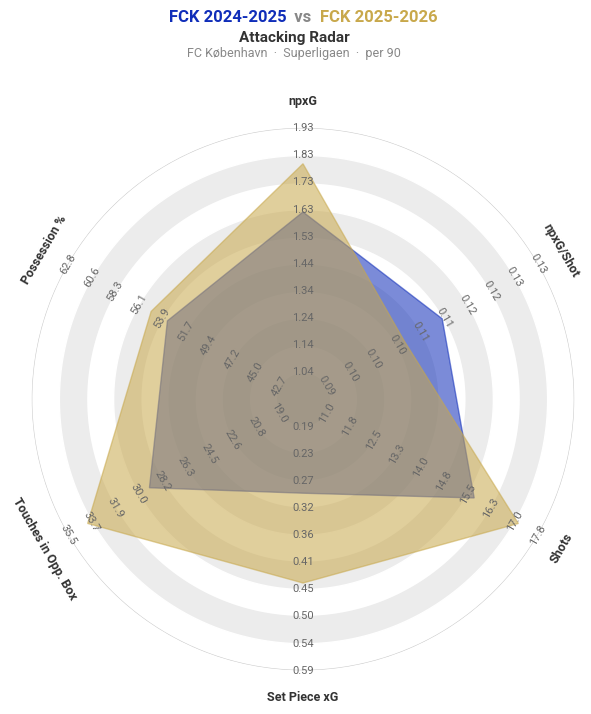

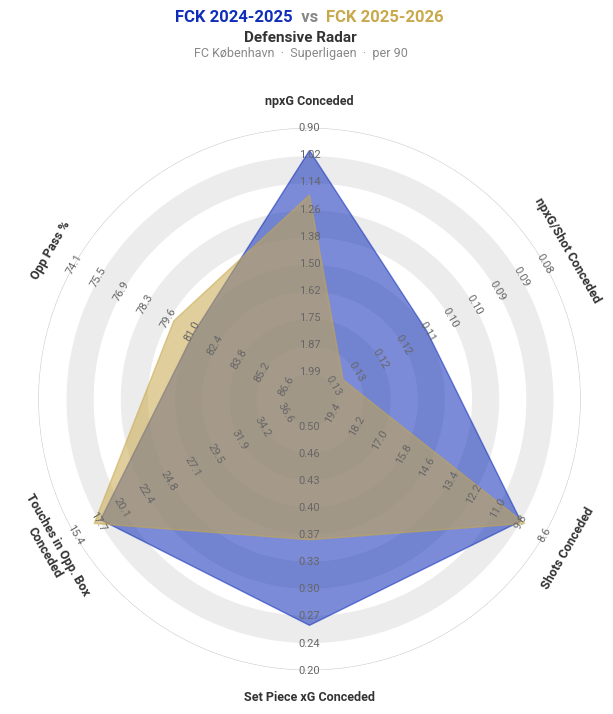

In [13]:
from viz.radar_chart import make_radar

make_radar(
    comp=comp, metrics=ATTACK_METRICS,
    season_a=s24, season_b=s25,
    label_a=f'FCK {s24}', label_b=f'FCK {s25}',
    team_a='FC København', team_b='FC København',
    title='Attacking Radar',
    subtitle=f'FC København  ·  Superligaen  ·  per 90',
    league_df=league_stats,
    save_path='fck_radar_attack.png',
)

make_radar(
    comp=comp, metrics=DEFENCE_METRICS,
    season_a=s24, season_b=s25,
    label_a=f'FCK {s24}', label_b=f'FCK {s25}',
    team_a='FC København', team_b='FC København',
    title='Defensive Radar',
    subtitle=f'FC København  ·  Superligaen  ·  per 90',
    league_df=league_stats,
    save_path='fck_radar_defence.png',
)


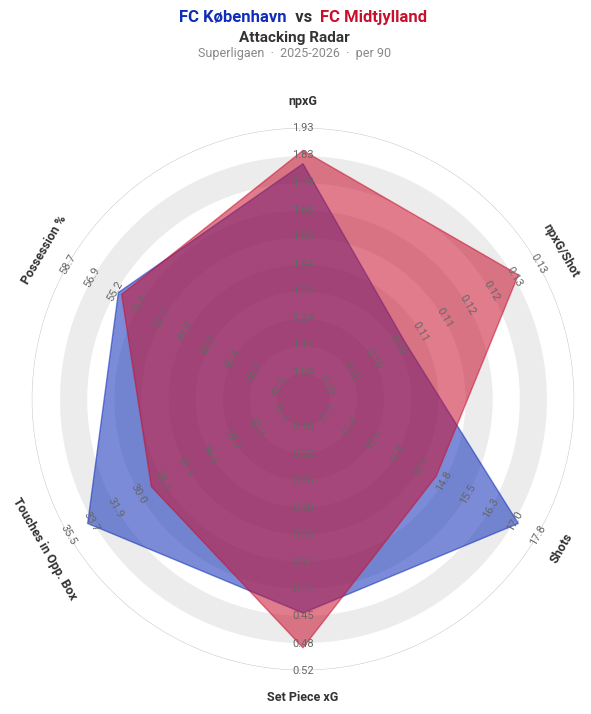

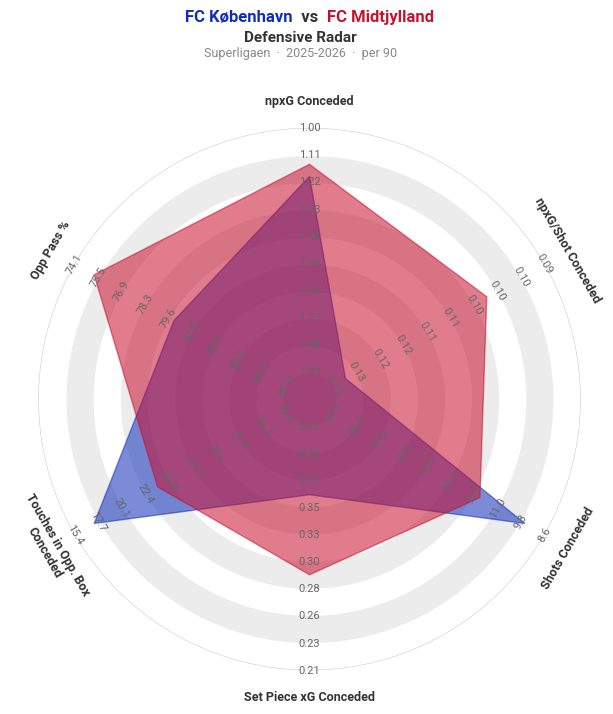

In [14]:
# ── Two-team radar: FCK vs FC Midtjylland, current season ────────────────
import pandas as pd
from viz.radar_chart import make_radar
from infra.data.feature_engineering.team_stats import get_standard_stats, ATTACK_METRICS, DEFENCE_METRICS

TEAM_A = 'FC København'
TEAM_B = 'FC Midtjylland'

all_stats = get_standard_stats(DB_PATH, 'Superligaen', seasons=[s25])

comp_two = pd.DataFrame({
    TEAM_A: all_stats[all_stats['team_name'] == TEAM_A].iloc[0],
    TEAM_B: all_stats[all_stats['team_name'] == TEAM_B].iloc[0],
}).T

make_radar(
    comp=comp_two, metrics=ATTACK_METRICS,
    season_a=TEAM_A, season_b=TEAM_B,
    label_a=TEAM_A, label_b=TEAM_B,
    team_a=TEAM_A, team_b=TEAM_B,
    title='Attacking Radar',
    subtitle=f'Superligaen  ·  {s25}  ·  per 90',
    league_df=all_stats,
)

make_radar(
    comp=comp_two, metrics=DEFENCE_METRICS,
    season_a=TEAM_A, season_b=TEAM_B,
    label_a=TEAM_A, label_b=TEAM_B,
    team_a=TEAM_A, team_b=TEAM_B,
    title='Defensive Radar',
    subtitle=f'Superligaen  ·  {s25}  ·  per 90',
    league_df=all_stats,
)


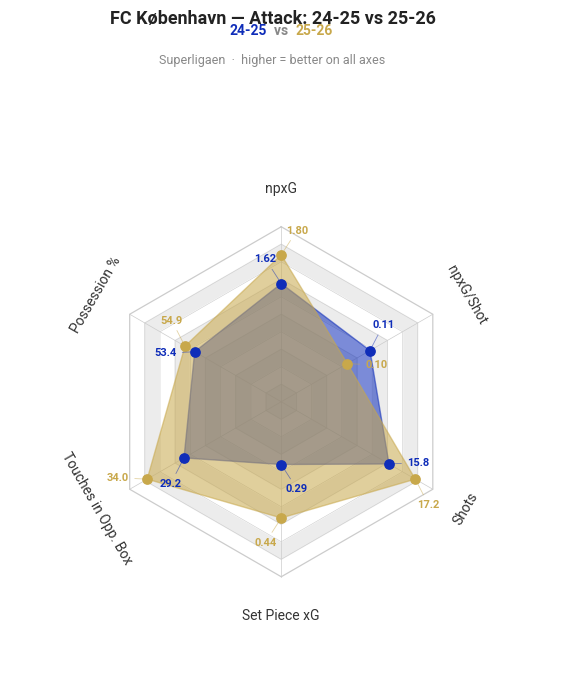

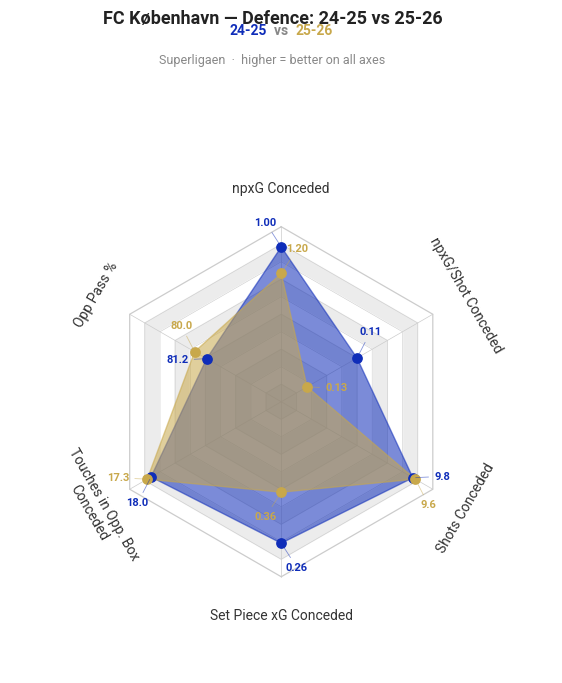

In [15]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.spider_chart import make_spider

DB = '/Users/admin/dev/algobetting/infra/data/db/fotmob.db'

# Same team, two seasons
make_spider(db_path=DB, league='Superligaen',
            team_a='FC København', season_a='2024-2025', season_b='2025-2026',
            chart='attack', save_path='fck_spider_attack.png')

make_spider(db_path=DB, league='Superligaen',
            team_a='FC København', season_a='2024-2025', season_b='2025-2026',
            chart='defence', save_path='fck_spider_defence.png')

# Two teams, same season
# make_spider(db_path=DB, league='Superligaen',
#             team_a='FC København', season_a='2025-2026',
#             team_b='FC Midtjylland', season_b='2025-2026',
#             chart='attack')


In [16]:
# =============================================================================
# xPts league table — Superligaen 2025-2026 (all shots incl. penalties)
# =============================================================================
from scipy.stats import poisson

conn = sqlite3.connect(DB_PATH)

xg_all = pd.read_sql("""
    SELECT match_id, teamId, SUM(expectedGoals) AS xg
    FROM shots
    WHERE league_id = 'Superligaen' AND season = '2025-2026'
    GROUP BY match_id, teamId
""", conn)

results = pd.read_sql("""
    SELECT match_id, home_team, away_team, home_goals, away_goals
    FROM matches
    WHERE league_id = 'Superligaen' AND season = '2025-2026'
""", conn)

names = pd.read_sql("SELECT team_id, team_name FROM team_id_mapping", conn)
conn.close()

# Build per-match, per-team rows
home = results[['match_id','home_team','away_team','home_goals','away_goals']].copy()
home = home.merge(
    xg_all.rename(columns={'teamId':'home_team','xg':'xg_for'}), on=['match_id','home_team'], how='left'
).merge(
    xg_all.rename(columns={'teamId':'away_team','xg':'xg_ag'}),  on=['match_id','away_team'], how='left'
)
home['team']       = home['home_team']
home['goals_for']  = home['home_goals']
home['goals_ag']   = home['away_goals']

away = results[['match_id','home_team','away_team','home_goals','away_goals']].copy()
away = away.merge(
    xg_all.rename(columns={'teamId':'away_team','xg':'xg_for'}), on=['match_id','away_team'], how='left'
).merge(
    xg_all.rename(columns={'teamId':'home_team','xg':'xg_ag'}),  on=['match_id','home_team'], how='left'
)
away['team']       = away['away_team']
away['goals_for']  = away['away_goals']
away['goals_ag']   = away['home_goals']

matches_long = pd.concat([
    home[['match_id','team','xg_for','xg_ag','goals_for','goals_ag']],
    away[['match_id','team','xg_for','xg_ag','goals_for','goals_ag']],
])

matches_long['actual_pts'] = np.where(
    matches_long['goals_for'] > matches_long['goals_ag'], 3,
    np.where(matches_long['goals_for'] == matches_long['goals_ag'], 1, 0)
)

MAX_GOALS = 10

def xpts_poisson(xg_for, xg_ag):
    win = draw = 0.0
    for i in range(MAX_GOALS + 1):
        for j in range(MAX_GOALS + 1):
            p = poisson.pmf(i, xg_for) * poisson.pmf(j, xg_ag)
            if i > j:    win  += p
            elif i == j: draw += p
    return 3 * win + draw

matches_long = matches_long.dropna(subset=['xg_for','xg_ag'])
matches_long['xpts'] = matches_long.apply(
    lambda r: xpts_poisson(r['xg_for'], r['xg_ag']), axis=1
)

table = matches_long.groupby('team').agg(
    Games      = ('match_id',   'count'),
    Goals_for  = ('goals_for',  'sum'),
    Goals_ag   = ('goals_ag',   'sum'),
    Actual_Pts = ('actual_pts', 'sum'),
    xPts       = ('xpts',       'sum'),
).round(1)

table['GD']          = table['Goals_for'] - table['Goals_ag']
table['Pts_vs_xPts'] = (table['Actual_Pts'] - table['xPts']).round(1)
table = table.merge(names, left_index=True, right_on='team_id').set_index('team_name')
table = table[['Games','Goals_for','Goals_ag','GD','Actual_Pts','xPts','Pts_vs_xPts']].sort_values('Actual_Pts', ascending=False)

table

,Games,Goals_for,Goals_ag,GD,Actual_Pts,xPts,Pts_vs_xPts
team_name,,,,,,,
AGF,24,47,24,23,52,44.6,7.4
FC Midtjylland,25,61,27,34,48,42.9,5.1
Sønderjyske,25,37,33,4,38,35.2,2.8
Viborg,24,39,36,3,37,35.5,1.5
Nordsjælland,24,40,39,1,37,33.5,3.5
Brøndby IF,24,31,23,8,35,34.8,0.2
FC København,25,44,38,6,32,42.1,-10.1
OB,24,39,48,-9,31,33.1,-2.1
Randers FC,24,25,30,-5,29,32.9,-3.9


In [34]:
# =============================================================================
# Datawrapper export — xPts league table
# =============================================================================
import sys, io, csv
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.logos import TEAM_LOGOS

# Aggregate xG totals with team names attached
xg_totals = (matches_long
    .merge(names, left_on='team', right_on='team_id', how='left')
    .groupby('team_name')
    .agg(xG_for=('xg_for','sum'), xG_ag=('xg_ag','sum'))
    .round(1)
)

dw = table.join(xg_totals)

# Diff columns
dw['Goals_vs_xG'] = (dw['Goals_for'] - dw['xG_for']).round(1)
dw['GA_vs_xGA']   = (dw['Goals_ag']  - dw['xG_ag']).round(1)
dw['Pts_vs_xPts'] = (dw['Actual_Pts'] - dw['xPts']).round(1)

dw = dw.sort_values(by='xPts', ascending=False)

def fmt_diff(val):
    return f"+{val}" if val > 0 else str(val)

out = io.StringIO()
w = csv.writer(out)
w.writerow(['Logo', 'Team', 'xPts', 'Pts vs xPts'])

for team_name, row in dw.iterrows():
    logo_url = TEAM_LOGOS.get(team_name, '')
    logo_md  = f"![]({logo_url})" if logo_url else ''
    w.writerow([
        logo_md,
        team_name,
        row['xPts'],
        fmt_diff(row['Pts_vs_xPts']),
    ])

print("--- COPY EVERYTHING BELOW THIS LINE ---")
print(out.getvalue())

--- COPY EVERYTHING BELOW THIS LINE ---
Logo,Team,xPts,Pts vs xPts
![](https://r2.thesportsdb.com/images/media/team/badge/vxuuts1473535487.png),AGF,44.6,+7.4
![](https://r2.thesportsdb.com/images/media/team/badge/s5bpcr1755712262.png),FC Midtjylland,42.9,+5.1
![](https://r2.thesportsdb.com/images/media/team/badge/styqtr1473535513.png),FC København,42.1,-10.1
![](https://r2.thesportsdb.com/images/media/team/badge/uvrpsp1447539333.png),Viborg,35.5,+1.5
![](https://r2.thesportsdb.com/images/media/team/badge/04mzis1677238771.png),Sønderjyske,35.2,+2.8
![](https://r2.thesportsdb.com/images/media/team/badge/ywswyw1473535498.png),Brøndby IF,34.8,+0.2
![](https://r2.thesportsdb.com/images/media/team/badge/p2hof41579460164.png),Nordsjælland,33.5,+3.5
![](https://r2.thesportsdb.com/images/media/team/badge/syyxwq1473535545.png),OB,33.1,-2.1
![](https://upload.wikimedia.org/wikipedia/en/thumb/b/b7/Randers_FC_logo.svg/250px-Randers_FC_logo.svg.png),Randers FC,32.9,-3.9
![](https://r2.thesportsdb.co

In [18]:
# =============================================================================
# 1. Home vs Away split
# =============================================================================
conn = sqlite3.connect(DB_PATH)
venue = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391 THEN 'Home' ELSE 'Away' END AS venue
    FROM np_matches
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)
conn.close()

df_venue = df.merge(venue, on='match_id', how='left')

home_away = df_venue.groupby(['season', 'venue']).agg(
    Games             = ('match_id',          'count'),
    npxG_for          = ('npxg_for',          'mean'),
    npxGA             = ('npxg_against',       'mean'),
    npxGD             = ('npxgd',             'mean'),
    Goals_for         = ('goals_for',         'mean'),
    Goals_against     = ('goals_against',     'mean'),
    Goals_minus_npxG  = ('goals_minus_npxg',  'mean'),
    GA_minus_npxGA    = ('ga_minus_npxga',    'mean'),
    Pens_for          = ('pens_for',          'sum'),
    Pens_against      = ('pens_against',      'sum'),
).round(3)

home_away.T

season           2024-2025         2025-2026        
venue                 Away    Home      Away    Home
Games               16.000  16.000    12.000  13.000
npxG_for             1.498   1.746     1.617   1.960
npxGA                1.227   0.771     1.245   1.155
npxGD                0.271   0.975     0.373   0.805
Goals_for            1.688   1.625     1.667   1.385
Goals_against        1.062   0.812     1.417   1.154
Goals_minus_npxG     0.190  -0.121     0.049  -0.576
GA_minus_npxGA      -0.165   0.041     0.172  -0.001
Pens_for             2.000   6.000     1.000   5.000
Pens_against         1.000   2.000     3.000   3.000

In [19]:
# =============================================================================
# 2. Big chances — created vs missed
# =============================================================================
conn = sqlite3.connect(DB_PATH)
big_chances = pd.read_sql("""
    SELECT m.match_id, m.season,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_big_chance ELSE ms.away_big_chance END  AS big_chances_for,
           CASE WHEN ms.home_team = 8391
                THEN ms.away_big_chance ELSE ms.home_big_chance END  AS big_chances_against,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_big_chance_missed_title
                ELSE ms.away_big_chance_missed_title END              AS big_chances_missed
    FROM match_stats ms
    JOIN np_matches m ON ms.match_id = m.match_id
    WHERE ms.league_id = 'Superligaen'
      AND (ms.home_team = 8391 OR ms.away_team = 8391)
""", conn)
conn.close()

for col in ['big_chances_for', 'big_chances_against', 'big_chances_missed']:
    big_chances[col] = pd.to_numeric(big_chances[col], errors='coerce')

# Conversion rate = (big chances - missed) / big chances
bc = big_chances.groupby('season').agg(
    Games              = ('match_id',           'count'),
    BigChances_for     = ('big_chances_for',     'sum'),
    BigChances_against = ('big_chances_against', 'sum'),
    BigChances_missed  = ('big_chances_missed',  'sum'),
).assign(
    BigChance_conversion_pct = lambda x: ((x['BigChances_for'] - x['BigChances_missed']) / x['BigChances_for'] * 100).round(1),
    BigChances_for_pg        = lambda x: (x['BigChances_for']     / x['Games']).round(2),
    BigChances_against_pg    = lambda x: (x['BigChances_against'] / x['Games']).round(2),
)

bc.T

season,2024-2025,2025-2026
Games,32.00,25.00
BigChances_for,89.00,71.00
BigChances_against,57.00,54.00
BigChances_missed,49.00,43.00
BigChance_conversion_pct,44.90,39.40
BigChances_for_pg,2.78,2.84
BigChances_against_pg,1.78,2.16


In [20]:
# =============================================================================
# 3. Red cards — minutes played with 10 men
# =============================================================================
conn = sqlite3.connect(DB_PATH)
red_cards = pd.read_sql("""
    SELECT rc.match_id, rc.season, rc.time,
           CASE WHEN rc.team_id = 8391 THEN 'FCK' ELSE 'Opponent' END AS team
    FROM red_cards rc
    WHERE rc.league_id = 'Superligaen'
      AND rc.match_id IN (
            SELECT DISTINCT match_id FROM np_shots
            WHERE teamId = 8391 AND league_id = 'Superligaen'
          )
""", conn)
conn.close()

red_cards['time'] = pd.to_numeric(red_cards['time'], errors='coerce')
red_cards['mins_reduced'] = (90 - red_cards['time']).clip(lower=0)

rc_summary = red_cards.groupby(['season', 'team']).agg(
    Red_cards       = ('match_id', 'count'),
    Avg_time        = ('time',          'mean'),
    Total_mins_10men= ('mins_reduced',  'sum'),
).round(1)

print("Red cards by season and team:")
print(rc_summary.to_string())
print()
print("Matches with a FCK red card:")
print(red_cards[red_cards['team'] == 'FCK'][['match_id','season','time']].to_string(index=False))

Red cards by season and team:
                    Red_cards  Avg_time  Total_mins_10men
season    team                                           
2024-2025 FCK               2      66.5                47
          Opponent          3      69.0                63
2025-2026 FCK               2      80.0                20
          Opponent          2      67.5                45

Matches with a FCK red card:
 match_id    season  time
  4801993 2025-2026    90
  4802046 2025-2026    70
  4494908 2024-2025    43
  4757620 2024-2025    90


In [21]:
# =============================================================================
# 4. Goalkeeper / shots on target — saves%, SoT against
# =============================================================================
conn = sqlite3.connect(DB_PATH)
gk = pd.read_sql("""
    SELECT m.match_id, m.season,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_ShotsOnTarget ELSE ms.away_ShotsOnTarget END AS sot_for,
           CASE WHEN ms.home_team = 8391
                THEN ms.away_ShotsOnTarget ELSE ms.home_ShotsOnTarget END AS sot_against,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_keeper_saves  ELSE ms.away_keeper_saves  END AS saves_for,
           CASE WHEN ms.home_team = 8391
                THEN ms.away_keeper_saves  ELSE ms.home_keeper_saves  END AS saves_against
    FROM match_stats ms
    JOIN np_matches m ON ms.match_id = m.match_id
    WHERE ms.league_id = 'Superligaen'
      AND (ms.home_team = 8391 OR ms.away_team = 8391)
""", conn)
conn.close()

for col in ['sot_for','sot_against','saves_for','saves_against']:
    gk[col] = pd.to_numeric(gk[col], errors='coerce')

gk_summary = gk.groupby('season').agg(
    Games        = ('match_id',    'count'),
    SoT_for_pg   = ('sot_for',    'mean'),
    SoT_ag_pg    = ('sot_against', 'mean'),
    Saves_pg     = ('saves_for',  'mean'),   # FCK GK saves per game
).round(2)

# Save % = saves / SoT against  (across full season)
totals = gk.groupby('season')[['sot_against','saves_for']].sum()
gk_summary['GK_save_pct'] = (totals['saves_for'] / totals['sot_against'] * 100).round(1)

# Opponent save % (FCK shots on target vs opponent saves)
totals2 = gk.groupby('season')[['sot_for','saves_against']].sum()
gk_summary['Opp_save_pct'] = (totals2['saves_against'] / totals2['sot_for'] * 100).round(1)

gk_summary.T

season,2024-2025,2025-2026
Games,32.00,25.00
SoT_for_pg,5.66,5.52
SoT_ag_pg,3.19,4.20
Saves_pg,2.06,2.68
GK_save_pct,64.70,63.80
Opp_save_pct,66.30,66.70


In [22]:
# =============================================================================
# 5. Within-season trend — 2025-26 first half vs second half
# =============================================================================
fck_25 = df[df['season'] == '2025-2026'].copy()
fck_25 = fck_25.merge(
    matches[['match_id','match_date']].drop_duplicates(), on='match_id', how='left'
)
fck_25['match_date'] = pd.to_datetime(fck_25['match_date'])
fck_25 = fck_25.sort_values('match_date').reset_index(drop=True)

mid = len(fck_25) // 2
fck_25['half'] = ['First half' if i < mid else 'Second half' for i in range(len(fck_25))]
fck_25['half_label'] = fck_25['half'] + ' (' + fck_25['match_date'].dt.strftime('%b %Y') + ')'

# Use first/last date of each half for label
labels = fck_25.groupby('half')['match_date'].agg(['min','max'])
fck_25['half_label'] = fck_25['half'].map(
    {h: f"{h}\n({labels.loc[h,'min'].strftime('%b %Y')}–{labels.loc[h,'max'].strftime('%b %Y')})"
     for h in labels.index}
)

trend = fck_25.groupby('half_label').agg(
    Games            = ('match_id',          'count'),
    npxG_for         = ('npxg_for',          'mean'),
    npxGA            = ('npxg_against',       'mean'),
    npxGD            = ('npxgd',             'mean'),
    Goals_for        = ('goals_for',         'mean'),
    Goals_against    = ('goals_against',     'mean'),
    Goals_minus_npxG = ('goals_minus_npxg',  'mean'),
    GA_minus_npxGA   = ('ga_minus_npxga',    'mean'),
    PSxG_diff_for    = ('psxg_diff_for',     'mean'),
    PSxG_diff_ag     = ('psxg_diff_ag',      'mean'),
    npxG_per_shot_ag = ('npxg_per_shot_ag',  'mean'),
    Pens_against     = ('pens_against',      'sum'),
).round(3)

# Sort chronologically
trend = trend.loc[sorted(trend.index)]
trend.T

half_label,First half\n(Jul 2025–Oct 2025),Second half\n(Oct 2025–Apr 2026)
Games,12.000,13.000
npxG_for,1.834,1.760
npxGA,1.082,1.305
npxGD,0.752,0.455
Goals_for,1.917,1.154
Goals_against,1.250,1.308
Goals_minus_npxG,0.083,-0.606
GA_minus_npxGA,0.168,0.002
PSxG_diff_for,0.254,0.001
PSxG_diff_ag,0.156,0.270


In [23]:
# =============================================================================
# 6. Player finishing — goals vs xG by season (all shots incl. penalties)
# =============================================================================
conn = sqlite3.connect(DB_PATH)
player_shots = pd.read_sql("""
    SELECT playerName, season, eventType,
           expectedGoals, expectedGoalsOnTarget
    FROM shots
    WHERE league_id = 'Superligaen'
      AND teamId = 8391
""", conn)
conn.close()

print("eventType values:", player_shots["eventType"].unique())
player_shots.head()


eventType values: <StringArray>
['Goal', 'AttemptSaved', 'Miss', 'Post']
Length: 4, dtype: str


,playerName,season,eventType,expectedGoals,expectedGoalsOnTarget
0,Pantelis Hatzidiakos,2024-2025,Goal,0.044814,0.319467
1,Mohamed Elyounoussi,2024-2025,AttemptSaved,0.206961,0.215253
2,Viktor Claesson,2024-2025,AttemptSaved,0.145404,0.000000
3,Mohamed Elyounoussi,2024-2025,Miss,0.024261,0.000000
4,Mohamed Elyounoussi,2024-2025,AttemptSaved,0.075925,0.079428


In [24]:
# =============================================================================
# 6b. Player finishing — Datawrapper export 2025-26 (min 5 shots)
# =============================================================================
import io, csv

player_shots['is_goal'] = (player_shots['eventType'] == 'Goal').astype(int)

p25 = (
    player_shots[player_shots['season'] == '2025-2026']
    .groupby('playerName')
    .agg(Shots=('expectedGoals', 'count'), xG=('expectedGoals', 'sum'), Goals=('is_goal', 'sum'))
    .reset_index()
)

p25['Over_Under'] = (p25['Goals'] - p25['xG']).round(2)
p25['xG']       = p25['xG'].round(2)
p25 = p25[p25['Shots'] >= 5].sort_values('xG', ascending=False)

out = io.StringIO()
w = csv.writer(out)
w.writerow(['Player', 'Shots', 'xG', 'Goals', 'Over/Under'])
for _, row in p25.iterrows():
    w.writerow([
        row['playerName'],
        int(row['Shots']),
        row['xG'],
        int(row['Goals']),
        row['Over_Under'],
    ])

print("--- PLAYER FINISHING 2025-26 — COPY BELOW FOR DATAWRAPPER ---")
print(out.getvalue())


--- PLAYER FINISHING 2025-26 — COPY BELOW FOR DATAWRAPPER ---
Player,Shots,xG,Goals,Over/Under
Youssoufa Moukoko,46,7.3,7,-0.3
Jordan Larsson,52,7.16,8,0.84
Mohamed Elyounoussi,59,6.47,6,-0.47
Viktor Claesson,29,6.01,3,-3.01
Elias Achouri,26,3.4,3,-0.4
Robert,34,3.12,4,0.88
Magnus Mattsson,11,2.53,2,-0.53
Andreas Cornelius,16,1.89,0,-1.89
Viktor Dadason,9,1.76,0,-1.76
Junnosuke Suzuki,21,1.14,1,-0.14
Gabriel Pereira,17,1.1,1,-0.1
Pantelis Hatzidiakos,11,1.06,2,0.94
Mads Emil Madsen,14,1.04,1,-0.04
Lukas Lerager,12,0.77,1,0.23
Marcos Lopez,18,0.71,1,0.29
Thomas Delaney,8,0.53,0,-0.53
William Clem,12,0.51,1,0.49
Mathias Jørgensen,5,0.36,0,-0.36



In [25]:
# =============================================================================
# 6c. Player finishing — season comparison table (min 5 shots in either season)
# =============================================================================
player_shots['is_goal'] = (player_shots['eventType'] == 'Goal').astype(int)

player = player_shots.groupby(['playerName', 'season']).agg(
    Shots = ('expectedGoals', 'count'),
    xG    = ('expectedGoals', 'sum'),
    Goals = ('is_goal',       'sum'),
).reset_index()

player['Over_Under']   = (player['Goals'] - player['xG']).round(2)
player['xG_per_shot']  = (player['xG'] / player['Shots']).round(3)
player['xG']           = player['xG'].round(2)

def season_cols(df, suffix):
    return df[['Shots','xG','Goals','Over_Under','xG_per_shot']].add_suffix(suffix)

p24 = season_cols(player[player['season'] == '2024-2025'].set_index('playerName'), '_24-25')
p25 = season_cols(player[player['season'] == '2025-2026'].set_index('playerName'), '_25-26')

comp_players = p24.join(p25, how='outer').fillna(0)

comp_players = comp_players[
    (comp_players['Shots_24-25'] >= 0) | (comp_players['Shots_25-26'] >= 0)
].sort_values('xG_25-26', ascending=False)

comp_players.style.background_gradient(
    subset=['Over_Under_24-25', 'Over_Under_25-26'],
    cmap='RdYlGn', vmin=-3, vmax=3
).background_gradient(
    subset=['xG_per_shot_24-25', 'xG_per_shot_25-26'],
    cmap='Blues', vmin=0.05, vmax=0.20
)


,Shots_24-25,xG_24-25,Goals_24-25,Over_Under_24-25,xG_per_shot_24-25,Shots_25-26,xG_25-26,Goals_25-26,Over_Under_25-26,xG_per_shot_25-26
playerName,,,,,,,,,,
Youssoufa Moukoko,0.000000,0.000000,0.000000,0.000000,0.000000,46.000000,7.300000,7.000000,-0.300000,0.159000
Jordan Larsson,31.000000,4.500000,8.000000,3.500000,0.145000,52.000000,7.160000,8.000000,0.840000,0.138000
Mohamed Elyounoussi,84.000000,8.930000,8.000000,-0.930000,0.106000,59.000000,6.470000,6.000000,-0.470000,0.110000
Viktor Claesson,37.000000,6.170000,6.000000,-0.170000,0.167000,29.000000,6.010000,3.000000,-3.010000,0.207000
Elias Achouri,33.000000,1.980000,2.000000,0.020000,0.060000,26.000000,3.400000,3.000000,-0.400000,0.131000
Robert,16.000000,2.380000,2.000000,-0.380000,0.149000,34.000000,3.120000,4.000000,0.880000,0.092000
Magnus Mattsson,39.000000,5.270000,3.000000,-2.270000,0.135000,11.000000,2.530000,2.000000,-0.530000,0.230000
Andreas Cornelius,31.000000,5.120000,3.000000,-2.120000,0.165000,16.000000,1.890000,0.000000,-1.890000,0.118000
Viktor Dadason,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.760000,0.000000,-1.760000,0.195000


In [26]:
comp_players

,Shots_24-25,xG_24-25,Goals_24-25,Over_Under_24-25,xG_per_shot_24-25,Shots_25-26,xG_25-26,Goals_25-26,Over_Under_25-26,xG_per_shot_25-26
playerName,,,,,,,,,,
Youssoufa Moukoko,0.0,0.00,0.0,0.00,0.000,46.0,7.30,7.0,-0.30,0.159
Jordan Larsson,31.0,4.50,8.0,3.50,0.145,52.0,7.16,8.0,0.84,0.138
Mohamed Elyounoussi,84.0,8.93,8.0,-0.93,0.106,59.0,6.47,6.0,-0.47,0.110
Viktor Claesson,37.0,6.17,6.0,-0.17,0.167,29.0,6.01,3.0,-3.01,0.207
Elias Achouri,33.0,1.98,2.0,0.02,0.060,26.0,3.40,3.0,-0.40,0.131
Robert,16.0,2.38,2.0,-0.38,0.149,34.0,3.12,4.0,0.88,0.092
Magnus Mattsson,39.0,5.27,3.0,-2.27,0.135,11.0,2.53,2.0,-0.53,0.230
Andreas Cornelius,31.0,5.12,3.0,-2.12,0.165,16.0,1.89,0.0,-1.89,0.118
Viktor Dadason,0.0,0.00,0.0,0.00,0.000,9.0,1.76,0.0,-1.76,0.195


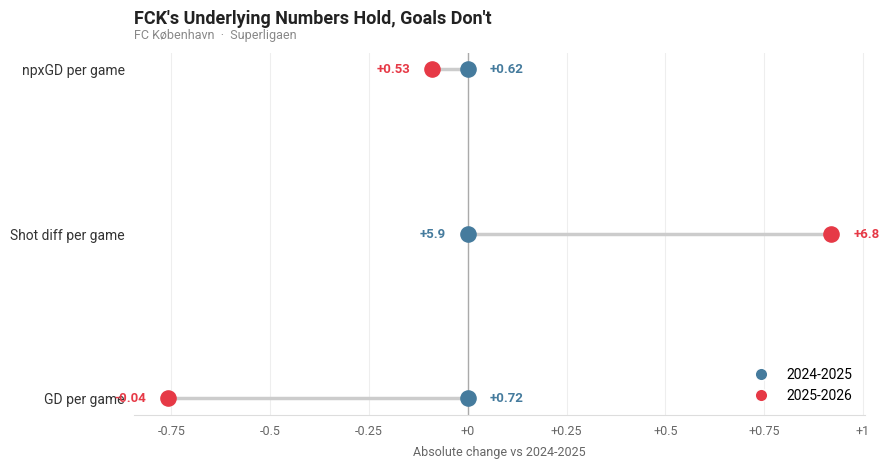

In [27]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Regular.ttf')
fm.fontManager.addfont('/Users/admin/Library/Fonts/Roboto-Bold.ttf')
plt.rcParams['font.family'] = 'Roboto'

# ── Metrics: (label, val_a, val_b, fmt) ──────────────────────────────────────
DUMBBELL_METRICS = [
    ('GD per game',         0.72, -0.04,  '{:+.2f}'),   # bottom
    ('Shot diff per game',  5.91,  6.83,  '{:+.1f}'),   # middle
    ('npxGD per game',      0.62,  0.53,  '{:+.2f}'),   # top
]

LABEL_A  = s24
LABEL_B  = s25
COLOR_A  = '#457b9d'
COLOR_B  = '#e63946'
TITLE    = "FCK's Underlying Numbers Hold, Goals Don't"
SUBTITLE = 'FC København  ·  Superligaen'

labels = [m[0] for m in DUMBBELL_METRICS]
vals_a = [m[1] for m in DUMBBELL_METRICS]
vals_b = [m[2] for m in DUMBBELL_METRICS]
fmts   = [m[3] for m in DUMBBELL_METRICS]
delta  = [b - a for a, b in zip(vals_a, vals_b)]

n  = len(labels)
ys = list(range(n))

fig, ax = plt.subplots(figsize=(9, 1.0 * n + 1.8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Lines ─────────────────────────────────────────────────────────────────────
for i, d in enumerate(delta):
    ax.plot([0, d], [ys[i], ys[i]], color='#cccccc',
            linewidth=2.5, zorder=1, solid_capstyle='round')

# ── Dots ─────────────────────────────────────────────────────────────────────
ax.scatter([0]*n, ys, color=COLOR_A, s=120, zorder=3, label=LABEL_A)
ax.scatter(delta,  ys, color=COLOR_B, s=120, zorder=3, label=LABEL_B)

# ── Data labels ───────────────────────────────────────────────────────────────
# Season A (at x=0): label on the INNER side (toward delta)
# Season B (at x=delta): label on the OUTER side (away from 0)
# This guarantees they are always on opposite sides of the line.
x_range = max(abs(d) for d in delta)
OFFSET = x_range * 0.06

for i, (va, vb, d, fmt) in enumerate(zip(vals_a, vals_b, delta, fmts)):
    if d >= 0:
        # delta goes right: A label left of 0, B label right of delta
        ax.text(-OFFSET, ys[i], fmt.format(va),
                ha='right', va='center', fontsize=9.5, color=COLOR_A, fontweight='bold')
        ax.text(d + OFFSET, ys[i], fmt.format(vb),
                ha='left',  va='center', fontsize=9.5, color=COLOR_B, fontweight='bold')
    else:
        # delta goes left: A label right of 0, B label left of delta
        ax.text(OFFSET, ys[i], fmt.format(va),
                ha='left',  va='center', fontsize=9.5, color=COLOR_A, fontweight='bold')
        ax.text(d - OFFSET, ys[i], fmt.format(vb),
                ha='right', va='center', fontsize=9.5, color=COLOR_B, fontweight='bold')

# ── Zero line ─────────────────────────────────────────────────────────────────
ax.axvline(0, color='#aaaaaa', linewidth=1, zorder=2)

# ── Row labels ────────────────────────────────────────────────────────────────
ax.set_yticks(ys)
ax.set_yticklabels(labels, fontsize=10, color='#333333')
ax.tick_params(left=False)

# ── x-axis ───────────────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.2g}'))
ax.tick_params(axis='x', labelsize=9, labelcolor='#666666', bottom=False)
ax.set_xlabel(f'Absolute change vs {s24}', fontsize=9, color='#666666', labelpad=6)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')
ax.yaxis.grid(False)
ax.xaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=COLOR_A, markersize=9, label=LABEL_A),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=COLOR_B, markersize=9, label=LABEL_B),
]
ax.legend(handles=handles, frameon=False, fontsize=10, loc='lower right')

# ── Title / subtitle ──────────────────────────────────────────────────────────
ax.text(0, 1.07, TITLE,    transform=ax.transAxes, fontsize=13,
        fontweight='bold', color='#222222', va='bottom')
ax.text(0, 1.03, SUBTITLE, transform=ax.transAxes, fontsize=9,
        color='#888888', va='bottom')

plt.tight_layout()
plt.savefig('fck_dumbbell.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()


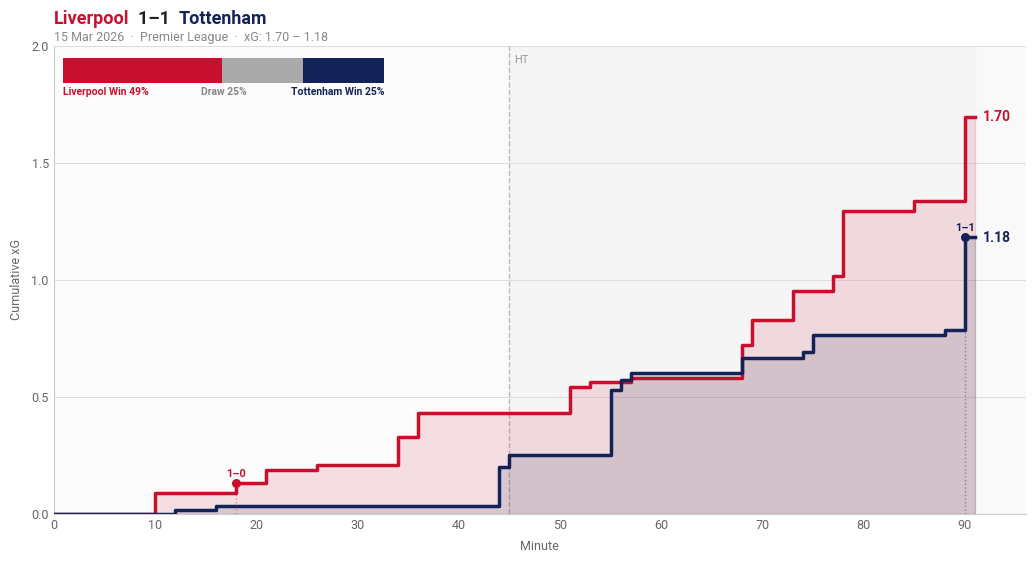

In [28]:
from viz.xg_race import plot_xg_race

# FCK vs Brøndby, 22 Mar 2026 (latest match)
plot_xg_race(
    db_path  = DB_PATH,
    match_id = 4813670,
    save_path= 'fck_xg_race_latest.png',
)


In [29]:
# =============================================================================
# Home / Away analysis — goals, xG, xGD per game (both seasons)
# =============================================================================
conn = sqlite3.connect(DB_PATH)

ha_raw = pd.read_sql("""
    SELECT
        m.season,
        CASE WHEN m.home_team = 8391 THEN 'Home' ELSE 'Away' END AS venue,
        m.match_id,
        CASE WHEN m.home_team=8391 THEN m.home_goals ELSE m.away_goals END AS goals_for,
        CASE WHEN m.home_team=8391 THEN m.away_goals ELSE m.home_goals END AS goals_against,
        xf.xg_for,
        xf.xg_ag  AS xg_against
    FROM matches m
    LEFT JOIN (
        SELECT match_id,
            SUM(CASE WHEN teamId=8391 THEN expectedGoals ELSE 0 END) AS xg_for,
            SUM(CASE WHEN teamId!=8391 THEN expectedGoals ELSE 0 END) AS xg_ag
        FROM shots
        WHERE league_id='Superligaen'
        GROUP BY match_id
    ) xf ON xf.match_id = m.match_id
    WHERE m.league_id='Superligaen'
      AND (m.home_team=8391 OR m.away_team=8391)
""", conn)
conn.close()

ha = (
    ha_raw.groupby(['season', 'venue'])
    .agg(
        Games         = ('match_id',     'count'),
        Goals_for     = ('goals_for',    'sum'),
        Goals_against = ('goals_against','sum'),
        xG_for        = ('xg_for',       'mean'),
        xG_against    = ('xg_against',   'mean'),
    )
    .reset_index()
)

ha['Goals_for_pg']     = (ha['Goals_for']     / ha['Games']).round(2)
ha['Goals_against_pg'] = (ha['Goals_against'] / ha['Games']).round(2)
ha['xGD']              = (ha['xG_for'] - ha['xG_against']).round(2)
ha['xG_for']           = ha['xG_for'].round(2)
ha['xG_against']       = ha['xG_against'].round(2)

# Pivot: one row per venue, columns split by season
def ha_cols(df, suffix):
    return (df.set_index('venue')
            [['Games','Goals_for_pg','Goals_against_pg','xG_for','xG_against','xGD']]
            .add_suffix(suffix))

h24 = ha_cols(ha[ha['season']=='2024-2025'], '_24-25')
h25 = ha_cols(ha[ha['season']=='2025-2026'], '_25-26')

ha_comp = h24.join(h25)

ha_comp.style.background_gradient(
    subset=['xGD_24-25','xGD_25-26'], cmap='RdYlGn', vmin=-1.5, vmax=1.5
).background_gradient(
    subset=['xG_for_24-25','xG_for_25-26'], cmap='Blues', vmin=0.8, vmax=2.8
).background_gradient(
    subset=['xG_against_24-25','xG_against_25-26'], cmap='Reds_r', vmin=0.6, vmax=2.0
)


,Games_24-25,Goals_for_pg_24-25,Goals_against_pg_24-25,xG_for_24-25,xG_against_24-25,xGD_24-25,Games_25-26,Goals_for_pg_25-26,Goals_against_pg_25-26,xG_for_25-26,xG_against_25-26,xGD_25-26
venue,,,,,,,,,,,,
Away,16,1.810000,1.120000,1.600000,1.280000,0.320000,12,1.750000,1.670000,1.680000,1.440000,0.240000
Home,16,1.940000,0.940000,2.040000,0.870000,1.170000,13,1.770000,1.380000,2.260000,1.340000,0.930000


In [30]:
# =============================================================================
# Home / Away — Datawrapper export
# =============================================================================
import io, csv

out = io.StringIO()
w = csv.writer(out)
w.writerow(['Season', 'Venue', 'Games', 'Goals For pg', 'Goals Against pg', 'xG For', 'xG Against', 'xGD'])

for _, row in ha.sort_values(['season','venue']).iterrows():
    w.writerow([
        row['season'],
        row['venue'],
        int(row['Games']),
        row['Goals_for_pg'],
        row['Goals_against_pg'],
        row['xG_for'],
        row['xG_against'],
        row['xGD'],
    ])

print("--- HOME/AWAY BREAKDOWN — COPY BELOW FOR DATAWRAPPER ---")
print(out.getvalue())


--- HOME/AWAY BREAKDOWN — COPY BELOW FOR DATAWRAPPER ---
Season,Venue,Games,Goals For pg,Goals Against pg,xG For,xG Against,xGD
2024-2025,Away,16,1.81,1.12,1.6,1.28,0.32
2024-2025,Home,16,1.94,0.94,2.04,0.87,1.17
2025-2026,Away,12,1.75,1.67,1.68,1.44,0.24
2025-2026,Home,13,1.77,1.38,2.26,1.34,0.93



FileNotFoundError: [Errno 2] No such file or directory: 'analysis/fck_fall/fck_ha_slope.png'

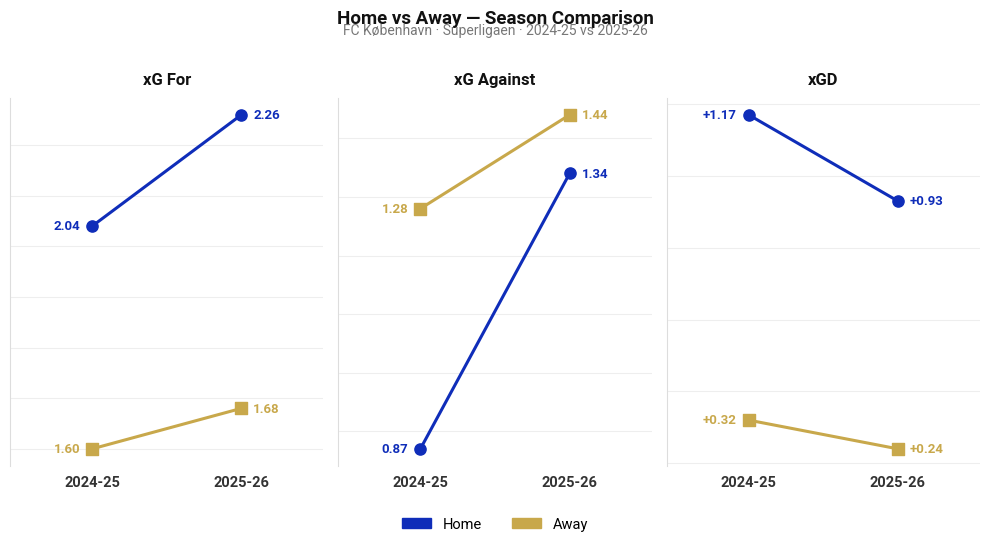

In [31]:
# =============================================================================
# Home / Away — Slope chart (season comparison)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FCK_BLUE = '#0F2DB9'
FCK_GOLD  = '#C8A84B'

METRICS = [
    ('xG_for',     'xG For'),
    ('xG_against', 'xG Against'),
    ('xGD',        'xGD'),
]

seasons       = ['2024-2025', '2025-2026']
season_labels = ['2024-25', '2025-26']
venues        = ['Home', 'Away']
venue_colors  = {'Home': FCK_BLUE, 'Away': FCK_GOLD}
venue_markers = {'Home': 'o', 'Away': 's'}

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.patch.set_facecolor('white')

for ax, (col, label) in zip(axes, METRICS):
    ax.set_facecolor('white')
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.tick_params(left=False, bottom=False, labelleft=False)
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(season_labels, fontsize=10.5, color='#333333', fontweight='bold')
    ax.set_xlim(-0.55, 1.55)
    ax.set_title(label, fontsize=12, fontweight='bold', pad=10, color='#111111')

    for venue in venues:
        color  = venue_colors[venue]
        marker = venue_markers[venue]
        vals = []
        for s in seasons:
            row = ha[(ha['season'] == s) & (ha['venue'] == venue)]
            vals.append(float(row[col].values[0]) if len(row) else np.nan)

        ax.plot([0, 1], vals, color=color, linewidth=2.2, zorder=3, solid_capstyle='round')
        ax.scatter([0, 1], vals, color=color, s=65, zorder=4, marker=marker)

        # Endpoint labels — xGD gets +/- sign
        fmt = '{:+.2f}' if col == 'xGD' else '{:.2f}'
        ax.text(-0.08, vals[0], fmt.format(vals[0]),
                ha='right', va='center', fontsize=9.5, color=color, fontweight='bold')
        ax.text(1.08, vals[1], fmt.format(vals[1]),
                ha='left',  va='center', fontsize=9.5, color=color, fontweight='bold')

home_patch = mpatches.Patch(color=FCK_BLUE, label='Home')
away_patch = mpatches.Patch(color=FCK_GOLD, label='Away')
fig.legend(handles=[home_patch, away_patch], loc='lower center', ncol=2,
           frameon=False, fontsize=10.5, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("Home vs Away — Season Comparison", fontsize=13.5, fontweight='bold',
             color='#111111', y=1.03)
fig.text(0.5, 0.98, 'FC København · Superligaen · 2024-25 vs 2025-26',
         ha='center', fontsize=10, color='#777777')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('analysis/fck_fall/fck_ha_slope.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()


In [ ]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.npxg_trend_chart import plot_xg_trend

plot_df_25 = (
    xg[xg['team_name'] == 'FC København']
    .merge(matches[['match_id', 'season']].drop_duplicates(), on='match_id', how='left')
    .query("season == '2025-2026'")
    .sort_values('match_date')
    .reset_index(drop=True)
)

# 5-game rolling (overrides the 10-game columns built in cell 1)
plot_df_25['xg_for_roll10']     = plot_df_25['xg_for'].rolling(5, min_periods=2).mean()
plot_df_25['xg_against_roll10'] = plot_df_25['xg_against'].rolling(5, min_periods=2).mean()
plot_df_25 = plot_df_25.dropna(subset=['xg_for_roll10', 'xg_against_roll10']).reset_index(drop=True)

plot_xg_trend(
    plot_df=plot_df_25,
    title="January and Buta's Arrival Coincided with a Worse Defence",
    team="FC København",
    league="Superligaen",
    save_path="analysis/fck_fall/fck_npxg_25_26.png",
    annotations=[('2025-10-01', "Huesca's injury"), ('2026-01-01', "Buta's debut")],
    roll_n=10,
)
